In [23]:
import pandas as pd
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [24]:
data = pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/merged files/csv/apple/apple_data.csv')

In [25]:
data

,Unnamed: 0,date,Price,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,0,2009-03-31,3.155715,9084.0,1620.0,43237.0,18926.0,24311.0,-3.23,0.15
1,1,2009-06-30,4.275764,9734.0,1828.0,48140.0,22252.0,25888.0,-3.98,0.16
2,2,2009-09-30,5.564229,12207.0,2532.0,47501.0,15861.0,31640.0,-3.13,0.12
3,3,2009-12-31,6.326139,15683.0,3378.0,53926.0,18158.0,35768.0,0.11,0.11
4,4,2010-03-31,7.054725,13499.0,3074.0,57057.0,17709.0,39348.0,1.75,0.20
...,...,...,...,...,...,...,...,...,...,...
61,61,2024-06-30,209.401932,85777.0,21448.0,331612.0,264904.0,66708.0,3.04,5.33
62,62,2024-09-30,231.920639,94930.0,14736.0,364980.0,308030.0,56950.0,2.72,4.83
63,63,2024-12-31,249.534180,124300.0,36330.0,344085.0,277327.0,66758.0,2.53,4.33
64,64,2025-03-31,221.587616,95359.0,24780.0,331233.0,264437.0,66796.0,1.99,4.33


In [26]:
# create column assets_liabilities_ratio
data['assets_liabilities_ratio'] = data['total_assets_musd'] / data['total_liabilities_musd']

# drop columns total_assets_musd total_liabilities_musd and other unnecessary columns
data = data.drop(columns=['total_assets_musd', 'total_liabilities_musd', 'Unnamed: 0'])

In [27]:
#1)rename date to ds and Price to y for prophet

data = data.rename(columns={"date": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d")

#reorder columns
data = data[["ds", "y", "revenue_musd", "net_income_musd", "assets_liabilities_ratio", "share_holder_equity_musd", "gdp_growth", "interest_rate"]]

#create backtesting data

data_bt = data.iloc[:-4]

data[40:]

,ds,y,revenue_musd,net_income_musd,assets_liabilities_ratio,share_holder_equity_musd,gdp_growth,interest_rate
40,2019-03-31,45.390228,58015.0,11561.0,1.448297,105860.0,1.93,2.42
41,2019-06-30,47.476837,53809.0,10044.0,1.427207,96456.0,2.24,2.40
42,2019-09-30,53.929817,64040.0,13686.0,1.364830,90488.0,2.80,1.83
43,2019-12-31,70.920349,91819.0,22236.0,1.356574,89531.0,3.35,1.55
44,2020-03-31,61.560169,58313.0,11249.0,1.324104,78425.0,1.28,0.05
45,2020-06-30,88.552185,59685.0,11253.0,1.294954,72282.0,-7.50,0.09
46,2020-09-30,112.650436,64698.0,12673.0,1.252714,65339.0,-1.41,0.09
47,2020-12-31,129.292557,111439.0,28755.0,1.230080,66224.0,-1.02,0.09
48,2021-03-31,119.200325,89584.0,23630.0,1.258146,69178.0,1.76,0.07
49,2021-06-30,133.879700,81434.0,21744.0,1.242055,64280.0,12.24,0.10


In [28]:
#2) Add a future base scenario so Proheet can make predictions

# ================== CONFIG ==================
FUTURE_PERIODS = 4    # nº de trimestres a predecir
FREQ = "Q"            # frecuencia trimestral
REG_COLS = ["revenue_musd", "net_income_musd", "assets_liabilities_ratio", "share_holder_equity_musd", "gdp_growth", "interest_rate"]

# ================== PREP ====================
df = data.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df[REG_COLS] = df[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates = {}
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:  #Calculate growth rates and append to dictionary
    growth_rates[col] = df[col].pct_change().mean(skipna=True)

growth_rates["gdp_growth"]=df["gdp_growth"].mean() #Cause gdp_growth is already a growth rate just calculate the mean
growth_rates["interest_rate"]=df["interest_rate"].mean() #Cause interest_rate is already a rate just calculate the mean


# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:
    gr = 0.0 if np.isnan(growth_rates[col]) else growth_rates[col]
    future[col] = [last[col] * (1 + gr) ** i for i in range(1, FUTURE_PERIODS+1)]

# Mantén constantes estos regresores (o pon tu propio escenario)
future["assets_liabilities_ratio"] = last["assets_liabilities_ratio"]
# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_10303/2203269307.py:42: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [29]:
#2) Replicate the same for backtesting data

# ================== PREP ====================
df_bt = data_bt.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df_bt["ds"] = pd.to_datetime(df_bt["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df_bt[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df_bt["gdp_growth"].dtype == "object":
    df_bt["gdp_growth"] = (
        df_bt["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df_bt[REG_COLS] = df_bt[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates_bt = {}
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:  #Calculate growth rates and append to dictionary
    growth_rates_bt[col] = df_bt[col].pct_change().mean(skipna=True)

growth_rates_bt["gdp_growth"]=df_bt["gdp_growth"].mean() #Cause gdp_growth is already a growth rate just calculate the mean
growth_rates_bt["interest_rate"]=df_bt["interest_rate"].mean() #Cause interest_rate is already a rate just calculate the mean


# Último punto observado
last_bt = df_bt.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future_bt = pd.DataFrame({"ds": future_dates_bt})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:
    gr_bt = 0.0 if np.isnan(growth_rates_bt[col]) else growth_rates_bt[col]
    future_bt[col] = [last_bt[col] * (1 + gr) ** i for i in range(1, FUTURE_PERIODS+1)]

# Mantén constantes estos regresores (o pon tu propio escenario)
future_bt["assets_liabilities_ratio"] = last_bt["assets_liabilities_ratio"]
# gdp_growth: mantener último valor (o define tu propio escenario macro)
future_bt["gdp_growth"] = last_bt["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future_bt["interest_rate"] = last_bt["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist_bt = df_bt[["ds", "y"] + REG_COLS].copy()
future_full_bt = pd.concat([hist_bt, future_bt], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_10303/1325257280.py:37: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [30]:
growth_rates_bt

{'revenue_musd': np.float64(0.07529464173336706),
 'net_income_musd': np.float64(0.1112978996722489),
 'share_holder_equity_musd': np.float64(0.02057524859694802),
 'gdp_growth': np.float64(2.0856451612903224),
 'interest_rate': np.float64(1.0941935483870966)}

In [31]:
#3) Initializa model and an train it

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6) Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))



14:22:45 - cmdstanpy - INFO - Chain [1] start processing
14:22:45 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
58 2023-09-30  169.955876  158.158822  182.196879  169.549286
59 2023-12-31  184.043306  171.055235  197.492136  190.913651
60 2024-03-31  181.714065  169.743156  194.145205  170.257339
61 2024-06-30  198.457704  185.648992  210.723459  209.401932
62 2024-09-30  205.915630  193.977695  218.688960  231.920639
63 2024-12-31  231.833154  219.684348  244.199295  249.534180
64 2025-03-31  212.908748  200.751683  225.788627  221.587616
65 2025-06-30  217.936920  205.000544  230.936085  204.937408
66 2025-09-30  232.110939  220.184882  244.930868         NaN
67 2025-12-31  229.348412  216.779283  242.710679         NaN
68 2026-03-31  249.222217  236.674456  261.671024         NaN
69 2026-06-30  259.967615  247.322930  272.001483         NaN


In [32]:
#3) Replicate the same for backtesting data

m_bt=Prophet()

for col in REG_COLS:
    m_bt.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df_bt = future_full_bt.dropna(subset=["y"]).copy()
m_bt.fit(train_df_bt)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df_bt = future_full_bt[["ds"] + REG_COLS].copy()
forecast_bt = m_bt.predict(predict_df_bt)

#6) Plot the results. Merge forecast with original data to compare
out_bt = forecast_bt[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df_bt[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out_bt.tail(12))

14:22:45 - cmdstanpy - INFO - Chain [1] start processing
14:22:45 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
54 2022-09-30  139.408847  128.569566  149.322160  136.052307
55 2022-12-31  152.202544  141.996156  161.751627  128.123062
56 2023-03-31  163.799811  153.503992  174.655545  162.854996
57 2023-06-30  165.266230  154.859382  175.975567  191.829453
58 2023-09-30  169.342959  159.074077  180.292984  169.549286
59 2023-12-31  190.033933  180.470869  200.825043  190.913651
60 2024-03-31  176.572783  166.639370  186.824236  170.257339
61 2024-06-30  191.034659  180.792380  202.000774  209.401932
62 2024-09-30  200.398961  189.983692  211.375884         NaN
63 2024-12-31  201.773624  191.365922  212.590500         NaN
64 2025-03-31  198.152071  187.663635  208.141267         NaN
65 2025-06-30  207.475395  197.005452  218.525004         NaN


In [33]:
#4) Merge prediction with actual y

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 7.425044901436729
RMSE: 96.202488495251
R²: 0.9808214635368359
           ds        yhat  yhat_lower  yhat_upper           y  is_future
58 2023-09-30  169.955876  158.158822  182.196879  169.549286      False
59 2023-12-31  184.043306  171.055235  197.492136  190.913651      False
60 2024-03-31  181.714065  169.743156  194.145205  170.257339      False
61 2024-06-30  198.457704  185.648992  210.723459  209.401932      False
62 2024-09-30  205.915630  193.977695  218.688960  231.920639      False
63 2024-12-31  231.833154  219.684348  244.199295  249.534180      False
64 2025-03-31  212.908748  200.751683  225.788627  221.587616      False
65 2025-06-30  217.936920  205.000544  230.936085  204.937408      False
66 2025-09-30  232.110939  220.184882  244.930868         NaN       True
67 2025-12-31  229.348412  216.779283  242.710679         NaN       True
68 2026-03-31  249.222217  236.674456  261.671024         NaN       True
69 2026-06-30  259.967615  247.322930  272.001483       

In [34]:
#4) Replicate the same for backtesting data

# Keep all rows (historical + future)
results_bt = forecast_bt[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data_bt.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results_bt["is_future"] = results_bt["y"].isna()

# Compute metrics only on historical rows
mask_bt = ~results_bt["is_future"]
mae_bt = mean_absolute_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
rmse_bt = mean_squared_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
r2_bt   = r2_score(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])

print("MAE:", mae_bt)
print("RMSE:", rmse_bt)
print("R²:", r2_bt)

# Show last 12 rows (will include future with y = NaN)
print(results_bt.tail(12))

MAE: 5.992670441593451
RMSE: 66.47203690011924
R²: 0.9816196697054886
           ds        yhat  yhat_lower  yhat_upper           y  is_future
54 2022-09-30  139.408847  128.569566  149.322160  136.052307      False
55 2022-12-31  152.202544  141.996156  161.751627  128.123062      False
56 2023-03-31  163.799811  153.503992  174.655545  162.854996      False
57 2023-06-30  165.266230  154.859382  175.975567  191.829453      False
58 2023-09-30  169.342959  159.074077  180.292984  169.549286      False
59 2023-12-31  190.033933  180.470869  200.825043  190.913651      False
60 2024-03-31  176.572783  166.639370  186.824236  170.257339      False
61 2024-06-30  191.034659  180.792380  202.000774  209.401932      False
62 2024-09-30  200.398961  189.983692  211.375884         NaN       True
63 2024-12-31  201.773624  191.365922  212.590500         NaN       True
64 2025-03-31  198.152071  187.663635  208.141267         NaN       True
65 2025-06-30  207.475395  197.005452  218.525004     

In [35]:
#5) Compare the actuall yhat with the yhat prediction for the backtesting period
comparison = results[["ds", "yhat"]]
comparison_bt = results_bt[["ds", "yhat"]]
comparison = comparison.merge(comparison_bt, on="ds", how="inner", suffixes=("_full", "_bt"))
comparison["absolute error"] = (comparison["yhat_full"] - comparison["yhat_bt"]).abs()
comparison["relative error"] = ((comparison["absolute error"] / comparison["yhat_full"])*100).round(1).astype(str)+"%"
print(comparison.tail(12))

           ds   yhat_full     yhat_bt  absolute error relative error
54 2022-09-30  155.740519  139.408847       16.331672          10.5%
55 2022-12-31  164.289463  152.202544       12.086918           7.4%
56 2023-03-31  168.302568  163.799811        4.502758           2.7%
57 2023-06-30  170.546172  165.266230        5.279942           3.1%
58 2023-09-30  169.955876  169.342959        0.612917           0.4%
59 2023-12-31  184.043306  190.033933        5.990627           3.3%
60 2024-03-31  181.714065  176.572783        5.141282           2.8%
61 2024-06-30  198.457704  191.034659        7.423045           3.7%
62 2024-09-30  205.915630  200.398961        5.516669           2.7%
63 2024-12-31  231.833154  201.773624       30.059530          13.0%
64 2025-03-31  212.908748  198.152071       14.756677           6.9%
65 2025-06-30  217.936920  207.475395       10.461525           4.8%


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_10303/3947255231.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


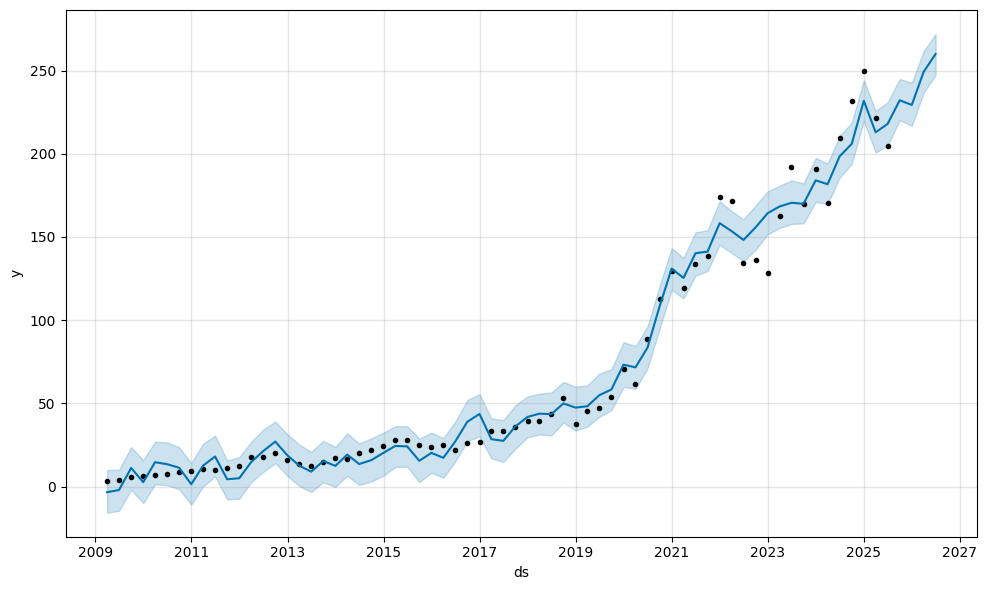

In [36]:
#5) Plot the results

figl = m.plot(forecast)
figl.show()

In [37]:
correlations = data.corr()
correlations

,ds,y,revenue_musd,net_income_musd,assets_liabilities_ratio,share_holder_equity_musd,gdp_growth,interest_rate
ds,1.000000,0.896642,0.897076,0.828750,-0.898139,-0.103263,0.268059,0.734807
y,0.896642,1.000000,0.826809,0.812212,-0.708760,-0.398544,0.221812,0.755515
revenue_musd,0.897076,0.826809,1.000000,0.974032,-0.791808,-0.027845,0.324747,0.613736
net_income_musd,0.828750,0.812212,0.974032,1.000000,-0.698976,-0.090467,0.346710,0.584884
assets_liabilities_ratio,-0.898139,-0.708760,-0.791808,-0.698976,1.000000,0.040950,-0.176853,-0.560672
share_holder_equity_musd,-0.103263,-0.398544,-0.027845,-0.090467,0.040950,1.000000,0.221838,-0.241026
gdp_growth,0.268059,0.221812,0.324747,0.346710,-0.176853,0.221838,1.000000,0.138662
interest_rate,0.734807,0.755515,0.613736,0.584884,-0.560672,-0.241026,0.138662,1.000000


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_10303/89357559.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl_bt.show()


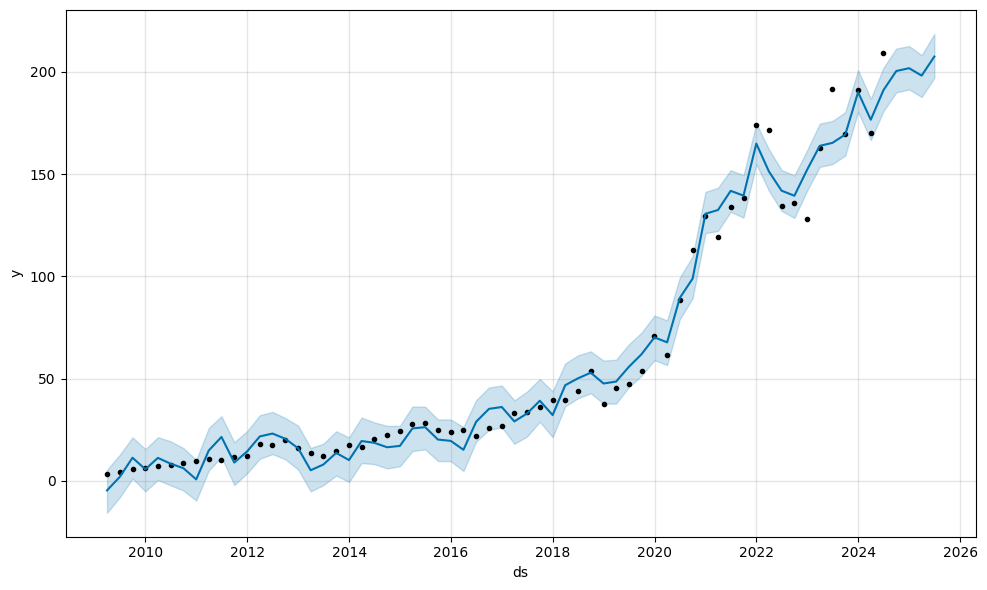

In [38]:
# 5) Plot the results for backtesting data

figl_bt = m_bt.plot(forecast_bt)
figl_bt.show()

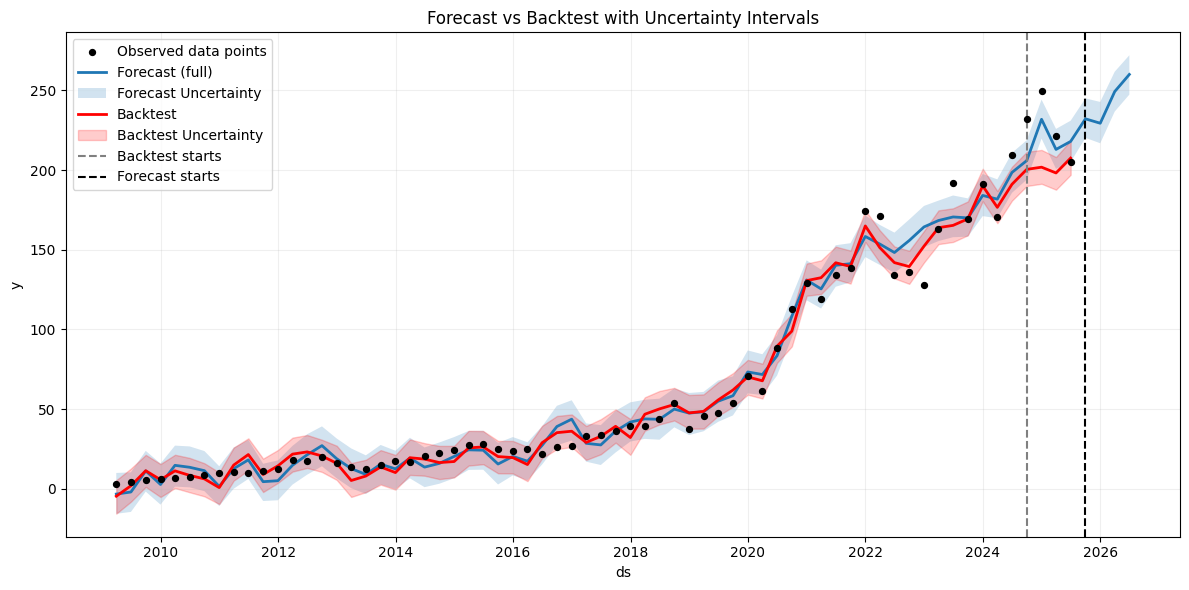

In [50]:
#6) Plot the results together

# --- Ensure datetime dtype
results['ds'] = pd.to_datetime(results['ds'])
results_bt['ds'] = pd.to_datetime(results_bt['ds'])

# --- Find split dates
bt_split   = results_bt.loc[results_bt['is_future'], 'ds'].min()   # ~2024-09-30
full_split = results.loc[results['is_future'], 'ds'].min()         # ~2025-09-30

fig, ax = plt.subplots(figsize=(12,6))

# Actuals (dots) from full dataset
mask_actual = ~results['is_future']
ax.scatter(results.loc[mask_actual, 'ds'],
           results.loc[mask_actual, 'y'],
           s=18, label='Observed data points', zorder=3, color='k')

# Forecast (full) line + CI
ax.plot(results['ds'], results['yhat'], label='Forecast (full)', linewidth=2)
ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.2, label='Forecast Uncertainty')

# Backtest line + CI
ax.plot(results_bt['ds'], results_bt['yhat'], label='Backtest', linewidth=2, color='red')
ax.fill_between(results_bt['ds'], results_bt['yhat_lower'], results_bt['yhat_upper'],
                alpha=0.2, label='Backtest Uncertainty', color='red')

# --- Vertical split lines
if pd.notna(bt_split):
    ax.axvline(bt_split, linestyle='--', linewidth=1.5, color='gray')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='gray', label='Backtest starts')

if pd.notna(full_split):
    ax.axvline(full_split, linestyle='--', linewidth=1.5, color='black')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='black', label='Forecast starts')

# Cosmetics
ax.set_title('Forecast vs Backtest with Uncertainty Intervals')
ax.set_xlabel('ds'); ax.set_ylabel('y')
# Deduplicate legend labels
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()